# HDX Benchmark REMD — Rg Convergence Analysis

Checking whether the 4-protein REMD simulations (200k steps, ff_2.1, T=0.80–0.95, 16 replicas) ran long enough for radius of gyration to stabilize.

In [1]:
import sys, os
from math import ceil
import numpy as np
import pandas as pd
import seaborn as sb
from scipy import stats
import mdtraj as md
import tables as tb
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

up_ver = "upside2-md"
upside_utils_dir = os.path.expanduser("~/.hermes/sandbox/{}/py".format(up_ver))
sys.path.append(upside_utils_dir)
import mdtraj_upside as mu

Very Important: All distances are in nanometers for MDTraj


In [2]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 'medium'
mpl.rcParams['ytick.labelsize'] = 'medium'
mpl.rcParams['xtick.labelsize'] = 'medium'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['svg.fonttype'] = 'none'

In [3]:
def radius_of_gyration(traj):
    """Compute Rg in nm using element masses."""
    xyz = traj.xyz
    masses = np.array([atom.element.mass for atom in traj.topology.atoms], dtype=np.float64)
    total_mass = np.sum(masses)
    com = np.sum(xyz * masses[None, :, None], axis=1) / total_mass
    diff = xyz - com[:, None, :]
    sq_dist = np.sum(diff ** 2, axis=2)
    rg_sq = np.sum(masses[None, :] * sq_dist, axis=1) / total_mass
    return np.sqrt(rg_sq)

def load_protein(run_dir, name, stride=10):
    """Load replica-0 trajectory and compute Rg."""
    h5 = os.path.join(run_dir, f"{name}.run.0.up")
    print(f"Loading {name} ... ", end="", flush=True)
    traj = mu.load_upside_traj(h5, stride=stride)
    rg = 10.0 * radius_of_gyration(traj)  # nm → Å
    time_ns = traj.time / 1000.0
    print(f"{traj.n_frames} frames, {traj.n_residues} res, Rg = {rg[-1]:.1f} Å")
    return time_ns, rg, traj

In [4]:
RUNS = os.path.expanduser("~/.hermes/workspace/hdx-md-benchmark/simulations")

proteins = {
    "NuG2b (1MI0, 61 res)":   "nug2b",
}

results = {}
for label, subdir in proteins.items():
    run_dir = os.path.join(RUNS, subdir, "outputs", "REMD")
    t, rg, traj = load_protein(run_dir, subdir, stride=10 if "NuG2b" in label else 20)
    results[label] = (t, rg, traj)

# Ubiquitin — may be locked if still running
try:
    run_dir = os.path.join(RUNS, "ubiquitin", "outputs", "ubiquitin_remd")
    t, rg, traj = load_protein(run_dir, "ubiquitin", stride=20)
    results["Ubiquitin (1UBQ, 76 res)"] = (t, rg, traj)
except Exception as e:
    print(f"Ubiquitin: SKIPPED (simulation still running)")

print(f"\nLoaded {len(results)} proteins")

Loading nug2b ... 

1000 frames, 56 res, Rg = 10.2 Å
Loading ubiquitin ... 

Ubiquitin: SKIPPED (simulation still running)

Loaded 1 proteins


In [5]:
# Convergence: compare first half vs second half Rg
rows = []
for name, (t, rg, traj) in results.items():
    n = len(rg)
    half = n // 2
    mean1, std1 = rg[:half].mean(), rg[:half].std()
    mean2, std2 = rg[half:].mean(), rg[half:].std()
    drift = abs(mean2 - mean1) / std1 if std1 > 0 else 0
    rows.append({
        "Protein": name.split(" (")[0],
        "Frames": n,
        "Rg final (Å)": f"{rg[-1]:.1f}",
        "1st half μ ± σ": f"{mean1:.2f} ± {std1:.2f}",
        "2nd half μ ± σ": f"{mean2:.2f} ± {std2:.2f}",
        "Drift (σ)": f"{drift:.2f}",
        "Verdict": "✓ Converged" if drift < 0.5 else ("~ Borderline" if drift < 1.0 else "✗ Not converged")
    })

df = pd.DataFrame(rows)
df

,Protein,Frames,Rg final (Å),1st half μ ± σ,2nd half μ ± σ,Drift (σ),Verdict
0,NuG2b,1000,10.2,10.23 ± 0.12,10.25 ± 0.13,0.20,✓ Converged


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


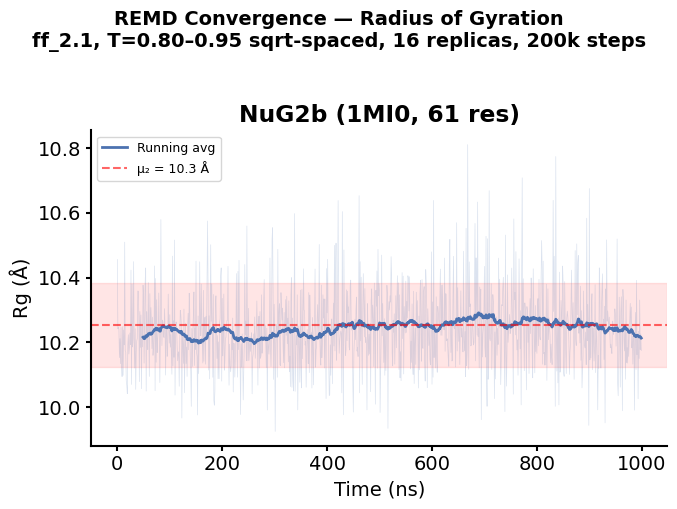

In [6]:
# Rg vs time plot
n_prots = len(results)
ncols = min(2, n_prots)
nrows = int(ceil(n_prots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
if n_prots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

colors = sb.color_palette("deep", n_prots)

for idx, (name, (t, rg, traj)) in enumerate(results.items()):
    ax = axes[idx]
    short = name.split(" (")[0]
    color = colors[idx]
    
    # Raw + running average
    window = max(1, len(rg) // 20)
    rg_smooth = np.convolve(rg, np.ones(window)/window, mode='valid')
    t_smooth = t[window - 1:]
    
    ax.plot(t, rg, alpha=0.2, color=color, linewidth=0.5)
    ax.plot(t_smooth, rg_smooth, color=color, linewidth=2, label="Running avg")
    
    # Second-half mean
    half = len(rg) // 2
    ax.axhline(rg[half:].mean(), color='red', linestyle='--', alpha=0.6,
               label=f"μ₂ = {rg[half:].mean():.1f} Å")
    
    # ±1σ band
    ax.axhspan(rg[half:].mean() - rg[half:].std(), rg[half:].mean() + rg[half:].std(),
               alpha=0.1, color='red')
    
    ax.set_title(f"{name}", fontweight='bold')
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Rg (Å)")
    ax.legend(fontsize=9, loc='best')
    sb.despine()

for idx in range(n_prots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("REMD Convergence — Radius of Gyration\nff_2.1, T=0.80–0.95 sqrt-spaced, 16 replicas, 200k steps",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


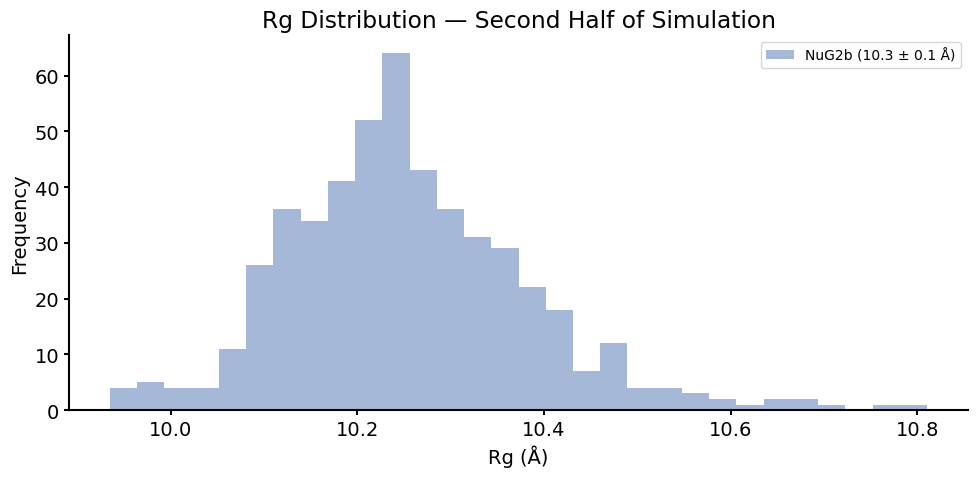

In [7]:
# Rg distribution (second half of simulation)
fig, ax = plt.subplots(figsize=(10, 5))

for idx, (name, (t, rg, traj)) in enumerate(results.items()):
    short = name.split(" (")[0]
    half = len(rg) // 2
    ax.hist(rg[half:], bins=30, alpha=0.5, label=f"{short} ({rg[half:].mean():.1f} ± {rg[half:].std():.1f} Å)",
            color=colors[idx])

ax.set_xlabel("Rg (Å)")
ax.set_ylabel("Frequency")
ax.set_title("Rg Distribution — Second Half of Simulation")
ax.legend(fontsize=10)
sb.despine()
plt.tight_layout()